# Duchenne Muscular Dystrophy: CRISPR-Corrected Isogenic Transcriptomics

## 01 — Data Loading, Quality Control and Differential Expression

Bulk RNA-seq analysis of a CRISPR-corrected isogenic DMD model (GEO [GSE189053](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE189053), Morera et al. 2022). A DMD patient-derived pluripotent stem cell line (**DMD-K2957fs**) is compared to its CRISPR-corrected isogenic control (**CORR-K2957fs**) across 5 time points of myogenic differentiation (Day -1, 0, 2, 5, 7), 4 replicates each.

This notebook loads and aggregates the raw Salmon quantifications, performs quality control, PCA, and per-day differential expression, exporting results for the functional enrichment analysis in `02_functional_enrichment.ipynb`.


In [1]:
import tarfile
from pathlib import Path

data_dir = Path("../data/raw")
raw_tar = data_dir / "GSE189053_RAW.tar"
extract_dir = data_dir / "salmon_quant"
extract_dir.mkdir(parents=True, exist_ok=True)

with tarfile.open(raw_tar, "r") as tar:
    tar.extractall(path=extract_dir)

sample_archives = sorted(extract_dir.glob("*.tar.gz"))
print("Sample archives found:", len(sample_archives))

for archive in sample_archives:
    sample_name = archive.name.split("_salmon.tar.gz")[0]
    sample_out_dir = extract_dir / sample_name
    sample_out_dir.mkdir(exist_ok=True)
    with tarfile.open(archive, "r:gz") as tar:
        tar.extractall(path=sample_out_dir)

print("Extraction complete.")

C:\Users\javie\AppData\Local\Temp\ipykernel_15032\3067108805.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Sample archives found: 40


C:\Users\javie\AppData\Local\Temp\ipykernel_15032\3067108805.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=sample_out_dir)


Extraction complete.


In [2]:
import pandas as pd

quant_files = sorted(extract_dir.glob("*/*/quant.sf"))
print("quant.sf files found:", len(quant_files))

example = pd.read_csv(quant_files[0], sep="\t")
print(example.shape)
example.head()

quant.sf files found: 40
(227464, 5)


,Name,Length,EffectiveLength,TPM,NumReads
0,ENST00000456328.2,1657,1515.000,0.000000,0.000
1,ENST00000450305.2,632,490.000,0.000000,0.000
2,ENST00000488147.1,1351,1237.387,3.883596,63.507
3,ENST00000619216.1,68,8.000,0.000000,0.000
4,ENST00000473358.1,712,570.000,0.000000,0.000


## Transcript-to-Gene Aggregation

Salmon quantifies at the transcript level. Transcripts are mapped to gene symbols using `mygene` and aggregated by summing `NumReads` per gene, to build a gene x sample count matrix and load the corresponding sample metadata (genotype, replicate, day).


In [3]:
!pip install mygene

In [4]:
import mygene

transcript_ids = example["Name"].str.split(".").str[0].unique().tolist()
print("Unique transcripts to map:", len(transcript_ids))

mg = mygene.MyGeneInfo()
results = mg.querymany(transcript_ids, scopes="ensembl.transcript", fields="symbol,ensembl.gene", species="human")

tx2gene = {}
for r in results:
    if "symbol" in r:
        tx2gene[r["query"]] = r["symbol"]

print("Transcripts successfully mapped:", len(tx2gene))

Unique transcripts to map: 227464


139 input query terms found dup hits:	[('ENST00000313835', 2), ('ENST00000460277', 2), ('ENST00000532574', 2), ('ENST00000528944', 2), ('E
4551 input query terms found no hit:	['ENST00000335137', 'ENST00000610542', 'ENST00000448179', 'ENST00000398216', 'ENST00000420190', 'ENS


Transcripts successfully mapped: 203689


In [5]:
tx2gene_series = pd.Series(tx2gene)

gene_counts = {}

for path in quant_files:
    sample_id = path.parts[-3].split("_")[0]
    df = pd.read_csv(path, sep="\t")
    df["transcript_id"] = df["Name"].str.split(".").str[0]
    df["gene"] = df["transcript_id"].map(tx2gene_series)
    df = df.dropna(subset=["gene"])
    gene_counts[sample_id] = df.groupby("gene")["NumReads"].sum()

counts_matrix = pd.DataFrame(gene_counts)
counts_matrix = counts_matrix.round().astype(int)

print(counts_matrix.shape)
counts_matrix.head()

(44407, 40)


,GSM5693941,GSM5693942,GSM5693943,GSM5693944,GSM5693945,GSM5693946,GSM5693947,GSM5693948,GSM5693949,GSM5693950,...,GSM5693971,GSM5693972,GSM5693973,GSM5693974,GSM5693975,GSM5693976,GSM5693977,GSM5693978,GSM5693979,GSM5693980
gene,,,,,,,,,,,,,,,,,,,,,
5S_rRNA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7SK,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
A1BG,299,213,226,84,123,221,185,168,72,117,...,144,92,66,85,131,146,138,67,85,86
A1BG-AS1,189,172,171,86,121,123,148,144,57,94,...,107,118,89,104,152,117,155,87,71,58
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [6]:
metadata_raw = [
    ("GSM5693941", "DMD", 1, -1), ("GSM5693942", "DMD", 1, 0), ("GSM5693943", "DMD", 1, 2), ("GSM5693944", "DMD", 1, 5), ("GSM5693945", "DMD", 1, 7),
    ("GSM5693946", "DMD", 2, -1), ("GSM5693947", "DMD", 2, 0), ("GSM5693948", "DMD", 2, 2), ("GSM5693949", "DMD", 2, 5), ("GSM5693950", "DMD", 2, 7),
    ("GSM5693951", "DMD", 3, -1), ("GSM5693952", "DMD", 3, 0), ("GSM5693953", "DMD", 3, 2), ("GSM5693954", "DMD", 3, 5), ("GSM5693955", "DMD", 3, 7),
    ("GSM5693956", "DMD", 4, -1), ("GSM5693957", "DMD", 4, 0), ("GSM5693958", "DMD", 4, 2), ("GSM5693959", "DMD", 4, 5), ("GSM5693960", "DMD", 4, 7),
    ("GSM5693961", "CORR", 1, -1), ("GSM5693962", "CORR", 1, 0), ("GSM5693963", "CORR", 1, 2), ("GSM5693964", "CORR", 1, 5), ("GSM5693965", "CORR", 1, 7),
    ("GSM5693966", "CORR", 2, -1), ("GSM5693967", "CORR", 2, 0), ("GSM5693968", "CORR", 2, 2), ("GSM5693969", "CORR", 2, 5), ("GSM5693970", "CORR", 2, 7),
    ("GSM5693971", "CORR", 3, -1), ("GSM5693972", "CORR", 3, 0), ("GSM5693973", "CORR", 3, 2), ("GSM5693974", "CORR", 3, 5), ("GSM5693975", "CORR", 3, 7),
    ("GSM5693976", "CORR", 4, -1), ("GSM5693977", "CORR", 4, 0), ("GSM5693978", "CORR", 4, 2), ("GSM5693979", "CORR", 4, 5), ("GSM5693980", "CORR", 4, 7),
]

metadata = pd.DataFrame(metadata_raw, columns=["sample_id", "genotype", "replicate", "day"])
metadata = metadata.set_index("sample_id")
metadata = metadata.loc[counts_matrix.columns]

metadata

,genotype,replicate,day
GSM5693941,DMD,1,-1
GSM5693942,DMD,1,0
GSM5693943,DMD,1,2
GSM5693944,DMD,1,5
GSM5693945,DMD,1,7
GSM5693946,DMD,2,-1
GSM5693947,DMD,2,0
GSM5693948,DMD,2,2
GSM5693949,DMD,2,5
GSM5693950,DMD,2,7


In [7]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

counts_matrix.to_csv(processed_dir / "gene_counts_matrix.csv")
metadata.to_csv(processed_dir / "sample_metadata.csv")

## Quality Control and PCA

Library size and gene detection are checked across all 40 samples, followed by PCA on the 2,000 most variable genes to examine the global structure of the data with respect to genotype and differentiation day.


In [8]:
library_sizes = counts_matrix.sum(axis=0)

qc_summary = metadata.copy()
qc_summary["library_size"] = library_sizes
qc_summary["n_genes_detected"] = (counts_matrix > 0).sum(axis=0)

qc_summary.sort_values("library_size")

,genotype,replicate,day,library_size,n_genes_detected
GSM5693968,CORR,2,2,5846983,17255
GSM5693969,CORR,2,5,5955831,17740
GSM5693963,CORR,1,2,6790594,17688
GSM5693962,CORR,1,0,7473178,17369
GSM5693949,DMD,2,5,7741172,18587
GSM5693964,CORR,1,5,8125345,18468
GSM5693970,CORR,2,7,8151341,18093
GSM5693967,CORR,2,0,8557150,17630
GSM5693980,CORR,4,7,8715584,18239
GSM5693966,CORR,2,-1,10117006,17895


In [9]:
qc_summary.groupby("genotype")["library_size"].agg(["mean", "median", "std"])

,mean,median,std
genotype,,,
CORR,11124482.15,11448526.0,3.620921e+06
DMD,15343342.05,16149289.5,3.112241e+06


In [10]:
qc_summary.groupby("replicate")["library_size"].agg(["mean", "median", "std"])

,mean,median,std
replicate,,,
1,13205291.3,12765318.0,4.941653e+06
2,10794191.7,9337078.0,4.478402e+06
3,14782753.5,14724341.5,2.223157e+06
4,14153411.9,14453925.5,2.875034e+06


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

log_counts = np.log2(counts_matrix + 1)

top_variable_genes = log_counts.var(axis=1).sort_values(ascending=False).head(2000).index
log_counts_hvg = log_counts.loc[top_variable_genes].T

scaler = StandardScaler()
scaled_data = scaler.fit_transform(log_counts_hvg)

pca = PCA(n_components=10)
pca_coords = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_coords[:, :2],
    columns=["PC1", "PC2"],
    index=log_counts_hvg.index
)
pca_df = pca_df.join(metadata)

print("Variance explained by PC1 and PC2:", pca.explained_variance_ratio_[:2])
pca_df.head()

Variance explained by PC1 and PC2: [0.50535854 0.12626026]


,PC1,PC2,genotype,replicate,day
GSM5693941,-38.625760,15.184097,DMD,1,-1
GSM5693942,-48.062048,8.367138,DMD,1,0
GSM5693943,3.648201,17.798980,DMD,1,2
GSM5693944,21.656392,22.973204,DMD,1,5
GSM5693945,23.477417,23.547975,DMD,1,7


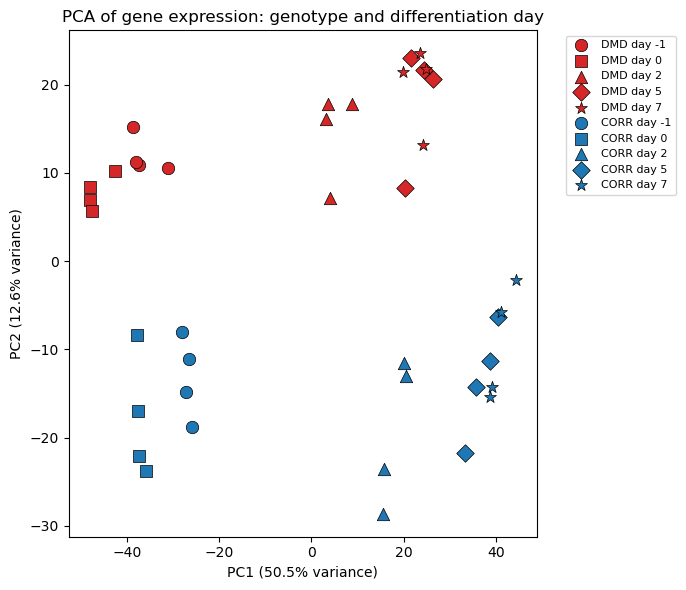

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

colors = {"DMD": "#d62728", "CORR": "#1f77b4"}
markers = {-1: "o", 0: "s", 2: "^", 5: "D", 7: "*"}

for genotype in ["DMD", "CORR"]:
    for day in [-1, 0, 2, 5, 7]:
        subset = pca_df[(pca_df["genotype"] == genotype) & (pca_df["day"] == day)]
        ax.scatter(
            subset["PC1"],
            subset["PC2"],
            c=colors[genotype],
            marker=markers[day],
            s=80,
            label=f"{genotype} day {day}",
            edgecolor="black",
            linewidth=0.5
        )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA of gene expression: genotype and differentiation day")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("../results/figures/01_1_pca_genotype_day.png", dpi=150, bbox_inches="tight")
plt.show()

## Differential Expression by Time Point

DMD vs CORR differential expression is performed independently at each of the 5 time points using PyDESeq2, followed by volcano plots and a targeted check of the calcium-handling genes (ATP2A1, RYR1, CASQ2, SLN, CACNA1H) highlighted in the original study.


In [13]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

de_results_by_day = {}

for day in [-1, 0, 2, 5, 7]:
    samples_day = metadata[metadata["day"] == day].index
    counts_day = counts_matrix[samples_day].T
    metadata_day = metadata.loc[samples_day]

    dds = DeseqDataSet(
        counts=counts_day,
        metadata=metadata_day,
        design_factors="genotype",
        refit_cooks=True
    )
    dds.deseq2()

    stat_res = DeseqStats(dds, contrast=["genotype", "DMD", "CORR"])
    stat_res.summary()

    de_results_by_day[day] = stat_res.results_df

    print(f"Day {day}: {(de_results_by_day[day]['padj'] < 0.05).sum()} genes with padj < 0.05")

C:\Users\javie\AppData\Local\Temp\ipykernel_15032\2924244098.py:11: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 6.11 seconds.

Fitting dispersion trend curve...
... done in 1.74 seconds.

Fitting MAP dispersions...
... done in 7.33 seconds.

Fitting LFCs...
... done in 4.94 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 6.25 seconds.



Log2 fold change & Wald test p-value: genotype DMD vs CORR
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene                                                                     
5S_rRNA         0.000000             NaN       NaN       NaN       NaN   
7SK             0.119461       -1.107201  3.869343 -0.286147  0.774766   
A1BG          192.352500        0.502863  0.170019  2.957694  0.003099   
A1BG-AS1      122.579190        0.101799  0.164443  0.619057  0.535879   
A1CF            0.000000             NaN       NaN       NaN       NaN   
...                  ...             ...       ...       ...       ...   
ZZEF1         848.464234       -0.084852  0.114619 -0.740292  0.459123   
ZZZ3          929.804083        0.002053  0.076145  0.026964  0.978488   
hsa-mir-1253    0.000000             NaN       NaN       NaN       NaN   
hsa-mir-423     0.000000             NaN       NaN       NaN       NaN   
snoZ196         0.000000             NaN       NaN   

C:\Users\javie\AppData\Local\Temp\ipykernel_15032\2924244098.py:11: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 6.16 seconds.

Fitting dispersion trend curve...
... done in 1.57 seconds.

Fitting MAP dispersions...
... done in 7.14 seconds.

Fitting LFCs...
... done in 5.05 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 5.81 seconds.



...

Log2 fold change & Wald test p-value: genotype DMD vs CORR
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene                                                                     
5S_rRNA         0.000000             NaN       NaN       NaN       NaN   
7SK             0.000000             NaN       NaN       NaN       NaN   
A1BG          110.583481        0.830037  0.229392  3.618426  0.000296   
A1BG-AS1       92.869050        0.422459  0.166294  2.540432  0.011072   
A1CF            0.000000             NaN       NaN       NaN       NaN   
...                  ...             ...       ...       ...       ...   
ZZEF1         930.879102       -0.152936  0.114379 -1.337094  0.181192   
ZZZ3          516.964046        0.212386  0.099025  2.144766  0.031972   
hsa-mir-1253    0.000000             NaN       NaN       NaN       NaN   
hsa-mir-423     0.000000             NaN       NaN       NaN       NaN   
snoZ196         0.000000             NaN       NaN   

C:\Users\javie\AppData\Local\Temp\ipykernel_15032\2924244098.py:11: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 6.64 seconds.

Fitting dispersion trend curve...
... done in 1.70 seconds.

Fitting MAP dispersions...
... done in 7.40 seconds.

Fitting LFCs...
... done in 5.28 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 6.12 seconds.



Log2 fold change & Wald test p-value: genotype DMD vs CORR
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene                                                                     
5S_rRNA         0.000000             NaN       NaN       NaN       NaN   
7SK             0.000000             NaN       NaN       NaN       NaN   
A1BG           76.679330       -0.114751  0.224735 -0.510606  0.609627   
A1BG-AS1       70.022760       -0.257331  0.200727 -1.281993  0.199845   
A1CF            0.000000             NaN       NaN       NaN       NaN   
...                  ...             ...       ...       ...       ...   
ZZEF1         827.585072        0.005151  0.116066  0.044380  0.964602   
ZZZ3          466.551109        0.326593  0.134822  2.422413  0.015418   
hsa-mir-1253    0.000000             NaN       NaN       NaN       NaN   
hsa-mir-423     0.000000             NaN       NaN       NaN       NaN   
snoZ196         0.000000             NaN       NaN   

C:\Users\javie\AppData\Local\Temp\ipykernel_15032\2924244098.py:11: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 6.51 seconds.

Fitting dispersion trend curve...
... done in 1.65 seconds.

Fitting MAP dispersions...
... done in 7.23 seconds.

Fitting LFCs...
... done in 5.41 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 5.79 seconds.



Log2 fold change & Wald test p-value: genotype DMD vs CORR
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene                                                                     
5S_rRNA         0.000000             NaN       NaN       NaN       NaN   
7SK             0.330354        0.415362  3.337846  0.124440  0.900967   
A1BG          102.689464        0.118264  0.190234  0.621677  0.534154   
A1BG-AS1       95.636481        0.068826  0.169593  0.405830  0.684868   
A1CF            0.000000             NaN       NaN       NaN       NaN   
...                  ...             ...       ...       ...       ...   
ZZEF1         943.257790        0.114645  0.087848  1.305040  0.191879   
ZZZ3          467.001781        0.248752  0.097991  2.538505  0.011133   
hsa-mir-1253    0.000000             NaN       NaN       NaN       NaN   
hsa-mir-423     0.000000             NaN       NaN       NaN       NaN   
snoZ196         0.000000             NaN       NaN   

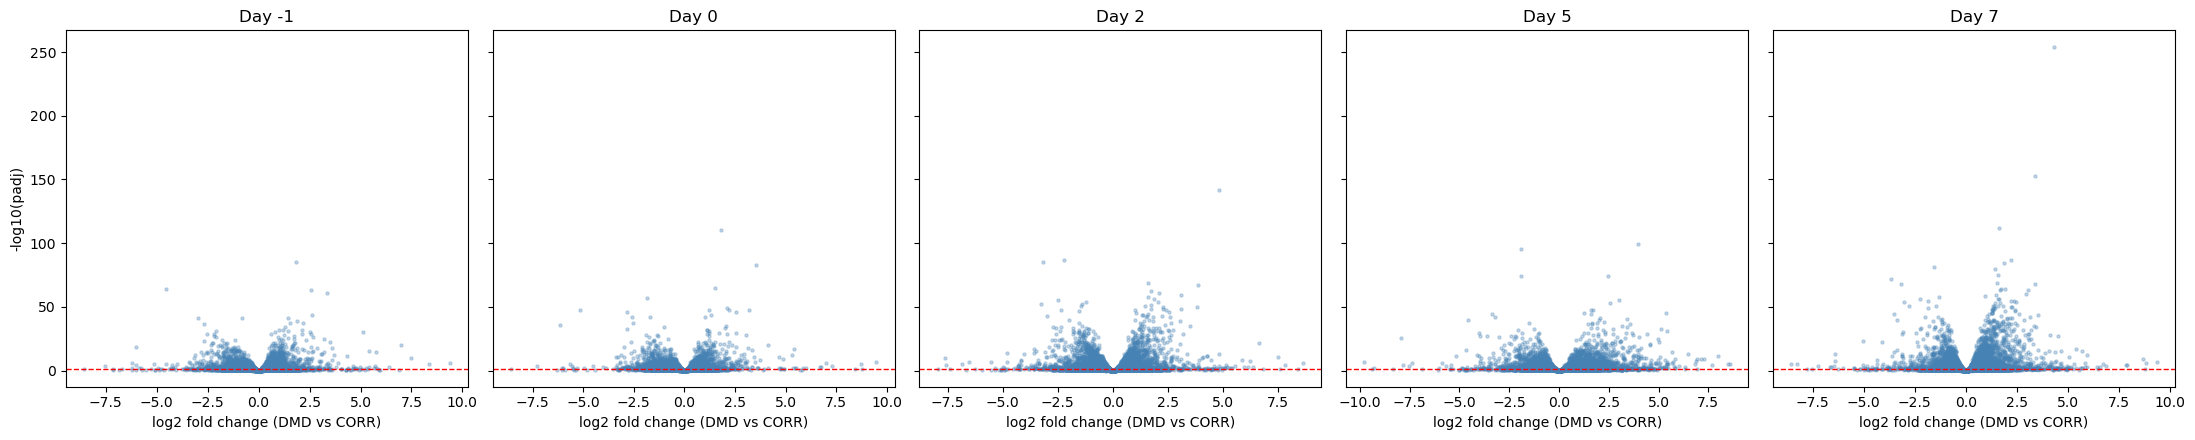

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)

days = [-1, 0, 2, 5, 7]

for ax, day in zip(axes, days):
    res = de_results_by_day[day].dropna(subset=["padj"])
    ax.scatter(
        res["log2FoldChange"],
        -np.log10(res["padj"].replace(0, 1e-300)),
        s=5,
        alpha=0.3,
        color="steelblue"
    )
    ax.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Day {day}")
    ax.set_xlabel("log2 fold change (DMD vs CORR)")

axes[0].set_ylabel("-log10(padj)")

plt.tight_layout()
plt.savefig("../results/figures/01_2_volcano_by_day.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
outlier_day2 = de_results_by_day[2].dropna(subset=["padj"]).sort_values("padj").head(5)
outlier_day2

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
ITGBL1,446.367004,4.827907,0.187348,25.769737,1.937214e-146,3.214807e-142
RAPSN,752.831159,-2.215296,0.109393,-20.250743,3.499229e-91,2.903485e-87
COBL,750.894999,-3.151175,0.156937,-20.079254,1.120645e-89,6.199037e-86
FBN1,16931.818907,1.605847,0.088620,18.120599,2.191939e-73,9.093806e-70
DSC3,202.016866,3.862545,0.216474,17.843037,3.274085e-71,1.086669e-67


In [16]:
calcium_genes = ["ATP2A1", "RYR1", "CASQ2", "SLN", "CACNA1H"]

calcium_summary = pd.DataFrame({
    day: {gene: de_results_by_day[day].loc[gene, "log2FoldChange"] if gene in de_results_by_day[day].index else None for gene in calcium_genes}
    for day in days
}).T

calcium_summary.index.name = "day"
calcium_summary

,ATP2A1,RYR1,CASQ2,SLN,CACNA1H
day,,,,,
-1,-0.667700,-0.915508,-1.154693,0.071210,-1.651107
0,-0.984505,-1.351404,-1.741685,-0.012705,-1.510814
2,-1.215368,-1.027729,-1.524649,-0.550750,-2.338027
5,-1.076823,-0.376696,-0.546904,-0.574631,-0.987260
7,-1.369868,-0.550416,-0.640273,-1.131078,-0.829841


In [17]:
calcium_padj = pd.DataFrame({
    day: {gene: de_results_by_day[day].loc[gene, "padj"] if gene in de_results_by_day[day].index else None for gene in calcium_genes}
    for day in days
}).T

calcium_padj.index.name = "day"
calcium_padj

,ATP2A1,RYR1,CASQ2,SLN,CACNA1H
day,,,,,
-1,8.727140e-02,5.576710e-02,1.093798e-02,9.137833e-01,1.893771e-16
0,6.251342e-03,5.947547e-04,8.097353e-05,9.911548e-01,1.273857e-01
2,7.663860e-55,5.233639e-09,1.119956e-32,4.637054e-02,3.421690e-48
5,2.159401e-24,1.926734e-03,1.346342e-05,4.467311e-02,1.099486e-17
7,1.084005e-42,4.229121e-09,3.343703e-10,1.798606e-11,2.310377e-15


Results are exported for use in the functional enrichment notebook.


In [18]:
for day, results in de_results_by_day.items():
    results.to_csv(processed_dir / f"de_results_day{day}.csv")